# Analíticas de Potencial Energético: Capa Gold
Este **Jupyter Notebook** contiene las gráficas y análisis para responder a las preguntas de negocio requeridas en el **Proyecto Integrador 4**, consumiendo directamente los resultados calculados por nuestra Capa de Analytics de PySpark.

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import glob
import os

# Configuraciones de estilo
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

# Cargar los datos desde los CSV exportados localmente en pasos anteriores
archivos_csv = glob.glob(os.path.join('..', '..', 'Avance0-Data', '**', '*.csv'), recursive=True)
if archivos_csv:
    df = pd.concat([pd.read_csv(f) for f in archivos_csv])
    # Convertir formatos correctos
    df['fecha_dia'] = pd.to_datetime(df['fecha_dia'])
    print("Datos cargados exitosamente:", df.shape)
else:
    print("No se encontraron archivos CSV. Asegurate de tener la carpeta 'Capa_Analytics' en el nivel raíz del proyecto.")

df.head()

Datos cargados exitosamente: (14, 14)


,dt,lat,lon,temp,humidity,wind_speed,clouds,source_stream,timestamp_str,fecha_dia,hora,mes,potencial_solar,potencial_eolico
0,1772717849,11.5364,-72.9214,27.02,69,5.66,20,weather_riohacha,2026-03-05 13:37:29,2026-03-05,13,3,17.62,56.6
1,1772890901,11.5384,-72.9168,25.01,78,4.12,20,weather_riohacha,2026-03-07 13:41:41,2026-03-07,13,3,16.01,41.2
2,1772755730,11.5384,-72.9168,27.01,78,3.60,0,weather_riohacha,2026-03-06 00:08:50,2026-03-06,0,3,0.00,36.0
3,1772811830,11.5384,-72.9168,27.79,69,8.23,40,weather_riohacha,2026-03-06 15:43:50,2026-03-06,15,3,14.23,82.3
4,1772852193,11.5384,-72.9168,27.79,69,8.94,0,weather_riohacha,2026-03-07 02:56:33,2026-03-07,2,3,0.00,89.4


## 1. ¿Cómo varía el potencial solar estimado a lo largo del día y del mes en ambas ubicaciones?

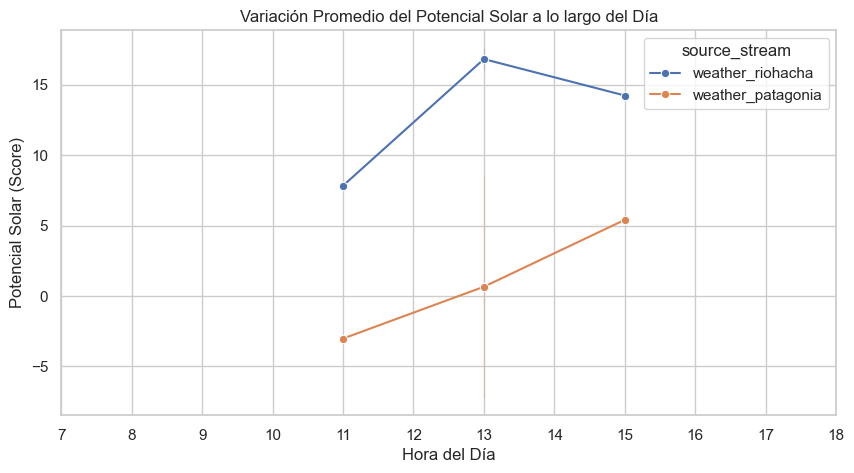

In [4]:
# Filtrar solo horas de día (7 a 18) como aproximación de horas solares
df_dia = df[(df['hora'] >= 7) & (df['hora'] <= 18)]

plt.figure(figsize=(10, 5))
sns.lineplot(data=df_dia, x='hora', y='potencial_solar', hue='source_stream', marker='o')
plt.title('Variación Promedio del Potencial Solar a lo largo del Día')
plt.xlabel('Hora del Día')
plt.ylabel('Potencial Solar (Score)')
plt.xticks(range(7, 19))
plt.show()

## 2. ¿Qué patrones históricos se observan en el potencial eólico?

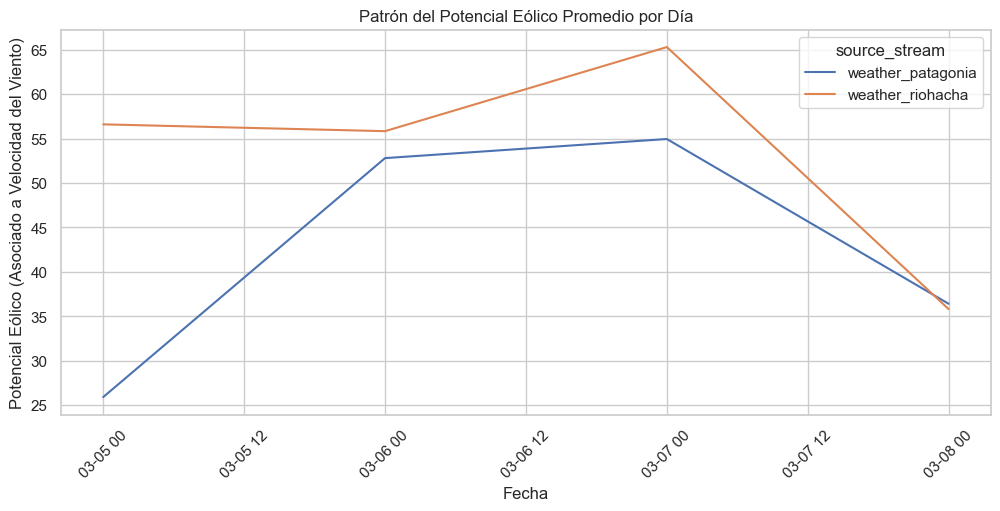

In [5]:
# Evolución del potencial eólico por fecha
df_diario_eol = df.groupby(['fecha_dia', 'source_stream'])['potencial_eolico'].mean().reset_index()

plt.figure(figsize=(12, 5))
sns.lineplot(data=df_diario_eol, x='fecha_dia', y='potencial_eolico', hue='source_stream')
plt.title('Patrón del Potencial Eólico Promedio por Día')
plt.xlabel('Fecha')
plt.xticks(rotation=45)
plt.ylabel('Potencial Eólico (Asociado a Velocidad del Viento)')
plt.show()

## 3. ¿Qué condiciones climáticas están asociadas con reducciones significativas en el potencial renovable?

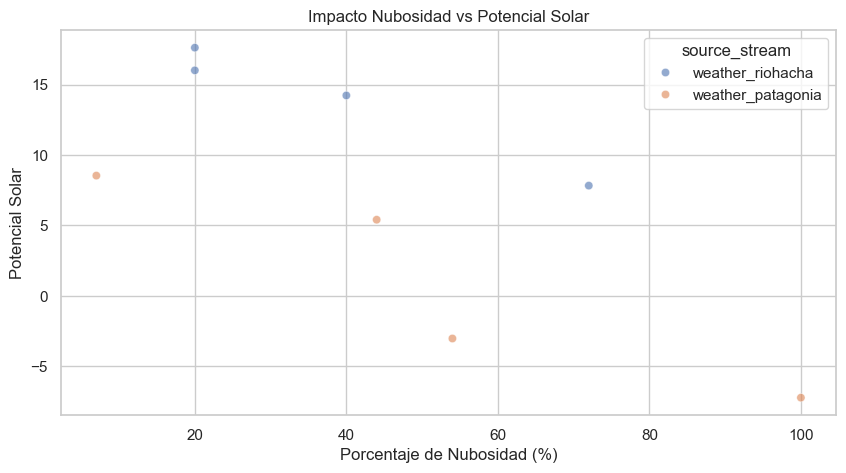

In [6]:
# Scatter plot para ver qué apaga el sol (Nubes)
plt.figure(figsize=(10, 5))
sns.scatterplot(data=df_dia, x='clouds', y='potencial_solar', hue='source_stream', alpha=0.6)
plt.title('Impacto Nubosidad vs Potencial Solar')
plt.xlabel('Porcentaje de Nubosidad (%)')
plt.ylabel('Potencial Solar')
plt.show()

## 5. ¿Cuáles fueron los días con mayor y menor potencial energético en cada ubicación?

In [7]:
df_picos = df.groupby(['source_stream', 'fecha_dia'])[['potencial_solar', 'potencial_eolico']].mean().reset_index()
print("Top 3 Días de MEJOR Potencial Solar (Patagonia):")
display(df_picos[df_picos['source_stream'] == 'weather_patagonia'].nlargest(3, 'potencial_solar'))

print("\nTop 3 Días de MEJOR Potencial Solar (Riohacha):")
display(df_picos[df_picos['source_stream'] == 'weather_riohacha'].nlargest(3, 'potencial_solar'))

print("\nPeor Día de Potencial Eólico Ambas Zonas:")
display(df_picos.loc[df_picos.groupby('source_stream')['potencial_eolico'].idxmin()])

Top 3 Días de MEJOR Potencial Solar (Patagonia):


,source_stream,fecha_dia,potencial_solar,potencial_eolico
0,weather_patagonia,2026-03-05,8.540000,25.9
1,weather_patagonia,2026-03-06,0.796667,52.8
3,weather_patagonia,2026-03-08,0.000000,36.4



Top 3 Días de MEJOR Potencial Solar (Riohacha):


,source_stream,fecha_dia,potencial_solar,potencial_eolico
4,weather_riohacha,2026-03-05,17.620000,56.600000
6,weather_riohacha,2026-03-07,8.005000,65.300000
5,weather_riohacha,2026-03-06,7.353333,55.833333



Peor Día de Potencial Eólico Ambas Zonas:


,source_stream,fecha_dia,potencial_solar,potencial_eolico
0,weather_patagonia,2026-03-05,8.54,25.9
7,weather_riohacha,2026-03-08,0.00,35.8
